In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [2]:
q1 = "Can I still join the course after the start date?"

v1 = model.encode(q1)

In [6]:
v1.shape

(384,)

In [3]:
v1

array([ 2.13904120e-02, -7.39799663e-02,  1.42068556e-03,  2.13816613e-02,
        2.45113149e-02,  3.15582752e-02, -1.10839702e-01, -1.05017498e-01,
       -6.18258938e-02, -6.42311852e-03,  3.72399064e-03,  9.06393602e-02,
       -9.49941017e-03,  6.53976873e-02,  1.10946558e-02, -2.10097339e-02,
       -3.35125513e-02, -4.31677327e-02,  9.96348727e-03,  1.41969863e-02,
       -6.40414879e-02, -7.04182126e-03, -7.91188031e-02,  5.80030754e-02,
        1.30212074e-03,  4.19733534e-03,  5.70979156e-02,  6.39447570e-02,
        2.49902904e-02, -3.95876691e-02, -3.79506797e-02,  2.70394552e-02,
        1.79423206e-02,  1.72272157e-02,  3.43311131e-02,  9.29055270e-03,
        5.86054735e-02, -4.97789569e-02, -5.05366083e-03,  4.34328541e-02,
       -1.56622957e-02, -2.97534503e-02, -5.13325352e-03,  5.13414629e-02,
        6.16060290e-03,  6.86980635e-02, -1.29505778e-02, -5.61938696e-02,
       -1.08265011e-02,  5.96683845e-02,  5.29939681e-02, -3.42755206e-02,
       -4.15274203e-02, -

In [ ]:
q2 = "I just found the course, is it possible to enroll now?"

v2 = model.encode(q2)

In [9]:
v1.dot(v2)

np.float32(0.66591626)

In [7]:
d  = "You don't need to register. You're accepted. You can also just start learning and submitting homework without registering."
dv = model.encode(d)

In [8]:
v1.dot(dv)

np.float32(0.32332397)

In [11]:
q3 = "How to install Docker on Windows?"
v3 = model.encode(q3)

In [12]:
v3.dot(dv)

np.float32(0.019730434)

That's the whole idea behind vector search: similar texts get similar vectors, and a dot product tells us how similar.

In [13]:
from ingest import load_faq_data

documents = load_faq_data()

In [14]:
texts = []

for doc in documents:
    text = doc["question"] + " " + doc["answer"]
    texts.append(text)

In [19]:
texts[10]

'Course: How many hours per week am I expected to spend on this course? It depends on your background and previous experience with modules. It is expected to require about 5 - 15 hours per week.\n\nYou can also calculate it yourself using [this data](https://github.com/DataTalksClub/zoomcamp-analytics/tree/main/data/de-zoomcamp-2023) and then update this answer.'

In [15]:
from tqdm.auto import tqdm

In [16]:
batch_size = 50
vectors = []

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    batch_vectors = model.encode(batch)
    vectors.extend(batch_vectors)

len(vectors)

  0%|          | 0/27 [00:00<?, ?it/s]

1350

In [17]:
import numpy as np
X = np.array(vectors)

In [18]:
X.shape

(1350, 384)

### VECTOR SEARCH

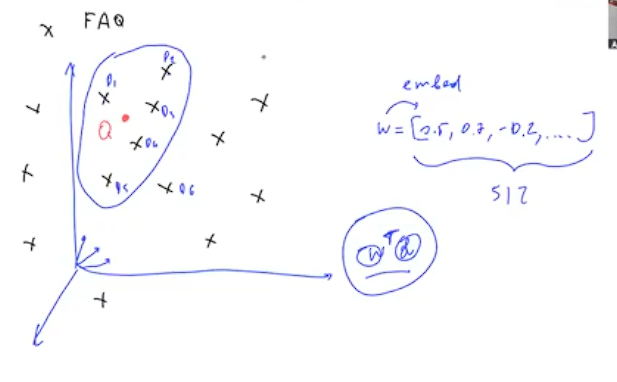

In [23]:
# Vector Vector multiplication

v1.dot(vectors[10])

# It is vetter to use vector matrix multiplication for better performance

np.float32(0.33153275)

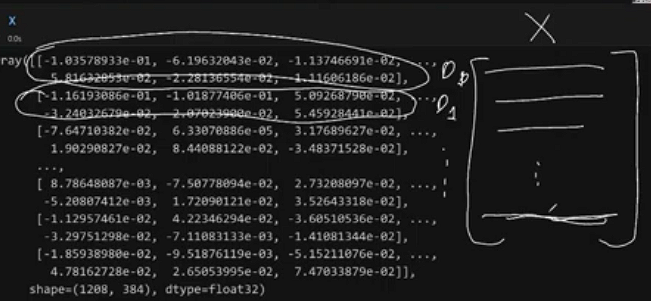

In [24]:
query = "Can I still join the course after the start date?"
v_query = model.encode(query)

In [25]:
scores = X.dot(v_query)

In [26]:
scores.shape

(1350,)

In [27]:
scores

array([ 0.48740575,  0.20991933,  0.762941  , ..., -0.08637968,
        0.03759792, -0.03037044], shape=(1350,), dtype=float32)

In [28]:
# Get the highst score
idx = np.argmax(scores)
idx, scores[idx]

(np.int64(2), np.float32(0.762941))

In [29]:
documents[idx]

{'course': 'data-engineering-zoomcamp',
 'section': 'General Course-Related Questions',
 'question': 'Course: Can I still join the course after the start date?',
 'answer': "Yes, even if you don't register, you're still eligible to submit the homework.\n\nBe aware, however, that there will be deadlines for turning in homeworks and the final projects. So don't leave everything for the last minute.",
 'doc_id': '3f1424af17'}

In [30]:
# Get the top 5 most similar questions
top5 = np.argsort(scores)[-5:]

In [31]:
top5 = top5[::-1]
top5

array([  2, 625, 907, 538,   7])

In [32]:
scores[top5]

array([0.762941  , 0.7579371 , 0.7192132 , 0.6536312 , 0.56009996],
      dtype=float32)

In [34]:
#  In one line:
top5 = np.argsort(-scores)[:5]

In [35]:
for idx in top5:
    print(scores[idx])
    print(documents[idx])
    print()

0.762941
{'course': 'data-engineering-zoomcamp', 'section': 'General Course-Related Questions', 'question': 'Course: Can I still join the course after the start date?', 'answer': "Yes, even if you don't register, you're still eligible to submit the homework.\n\nBe aware, however, that there will be deadlines for turning in homeworks and the final projects. So don't leave everything for the last minute.", 'doc_id': '3f1424af17'}

0.7579371
{'course': 'mlops-zoomcamp', 'section': 'General Course-Related Questions', 'question': 'Course - Can I still join the course after the start date?', 'answer': "Yes, even if you don't register, you're still eligible to submit the homeworks as long as the form is still open and accepting submissions.\n\nBe aware, however, that there will be deadlines for turning in the final projects. So don't leave everything to the last minute.", 'doc_id': '2d8b16c2a0'}

0.7192132
{'course': 'machine-learning-zoomcamp', 'section': 'General Course-Related Questions', 

Doing this by hand with numpy is fine for a small dataset. A larger one needs a library that also handles filtering and ranking. That's what we turn to next. --> minsearch

In [36]:
from minsearch import VectorSearch

vindex = VectorSearch(keyword_fields=["course"])
vindex.fit(X, documents)

In [37]:
query = "I just discovered the course. Can I still join it?"
query_vector = model.encode(query)

results = vindex.search(query_vector, num_results=5)

In [40]:
len(results)

5

In [44]:
results[0]

{'course': 'llm-zoomcamp',
 'section': 'General Course-Related Questions',
 'question': 'I just discovered the course. Can I still join?',
 'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.',
 'doc_id': '74eb249bbf'}

In [45]:
results = vindex.search(
    query_vector,
    filter_dict={"course": "llm-zoomcamp"},
    num_results=5
)

In [49]:
results[1]

{'course': 'llm-zoomcamp',
 'section': 'General Course-Related Questions',
 'question': 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
 'answer': 'No, you can only get a certificate if you finish the course with a "live" cohort.\n\nWe don\'t award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project.\n\nYou can only peer-review projects at the time the course is running; after the form is closed and the peer-review list is compiled.',
 'doc_id': '69d122f12e'}

### RAG WITH VECTOR SEARCH

First let's recap Text search

In [50]:
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
openai_client = OpenAI()

In [51]:
from ingest import load_faq_data, build_index

documents = load_faq_data()
index = build_index(documents)

In [53]:
from rag_helper import RAGBase

assistant = RAGBase(
    index=index,
    llm_client=openai_client,
)

In [54]:
query = "I just found out about the program, can I still sign up?"
assistant.rag(query)

'Yes, you can still join. If you want a certificate, make sure to submit your project while submissions are still being accepted.'

Now with vector Search:

In [55]:
assistant.search(query, num_results=5)

[{'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.',
  'doc_id': '74eb249bbf'},
 {'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I missed the first homework - can I still get a certificate?',
  'answer': 'Yes, you need to pass the Capstone project to get the certificate. Homework is not mandatory, though it is recommended for reinforcing concepts, and the points awarded count towards your rank on the leaderboard.',
  'doc_id': '9f689c185f'},
 {'course': 'llm-zoomcamp',
  'section': 'Module 2: Vector Search',
  'question': 'Do I need a new GitHub repo for Module 2, or just a new codespace?',
  'answer': "Just a new codespace. A codespace is an environment (see *Can I run the course locally instead of Codespaces?*); you creat

In [56]:

class RAGVector(RAGBase):

    def __init__(self, embedder, **kwargs):
        super().__init__(**kwargs)
        self.embedder = embedder

    def search(self, query, num_results=5):
        query_vector = self.embedder.encode(query)
        filter_dict = {"course": self.course}

        return self.index.search(
            query_vector,
            num_results=num_results,
            filter_dict=filter_dict
        )

In [57]:
vector_assistant = RAGVector(
    embedder=model,
    index=vindex,
    llm_client=openai_client,
)

In [58]:
query = "I just found out about the program, can I still sign up?"
vector_assistant.rag(query)

'Yes, you can still join. If you want to receive a certificate, you need to submit your project while submissions are still open.'

In [59]:
vector_assistant.rag("the program has already begun, can I still sign up?")

'Yes — you can still join even after the program has begun.\n\nIf you want a certificate, make sure to submit your project while submissions are still being accepted.'

In [60]:
vector_assistant.rag("the program is active now, can I inscribe now?")

'Yes, you can start now. You don’t need to wait for a confirmation email, and registration isn’t required to begin learning or submitting homework while the form is open.'

In [61]:
assistant.rag("the program is active now, can I inscribe now?")

"I don't know."

### SAVING TO A PERSISTENT DATA

In [63]:
from sqlitesearch import VectorSearchIndex

vs_index = VectorSearchIndex(
    keyword_fields=["course"],
    mode="ivf",
    db_path="faq_vectors2.db"
)

# Mode is how the vector search is performed (the type of nearest neighbor search). 

In [64]:
vs_index.fit(vectors, documents)

In [65]:
query = "I just discovered the course. Can I still join it?"
query_vector = model.encode(query)

results = vs_index.search(query_vector, num_results=5)

In [66]:
results

[{'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.',
  'doc_id': '74eb249bbf'},
 {'course': 'machine-learning-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'The course has already started. Can I still join it?',
  'answer': 'Yes, you can. Even though you missed the start date, you can register for the course. You won’t be able to submit some of the homeworks, but you can still take part in the course.\n\nIn order to get a certificate, you need to submit 2 out of 3 course projects and review 3 peers by the deadline. It means that if you join the course at the end of November and manage to work on two projects, you will still be eligible for a certificate.',
  'doc_id': '41aabbd7c5'},
 {'course': 'mlops-zoomcamp',
  'section': 'General Cour

In [67]:
results = vs_index.search(
    query_vector,
    filter_dict={"course": "llm-zoomcamp"},
    num_results=5
)

results

[{'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.',
  'doc_id': '74eb249bbf'},
 {'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
  'answer': 'No, you can only get a certificate if you finish the course with a "live" cohort.\n\nWe don\'t award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project.\n\nYou can only peer-review projects at the time the course is running; after the form is closed and the peer-review list is compiled.',
  'doc_id': '69d122f12e'},
 {'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'When will the course be offere

In [68]:
vs_index.close()